In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load the dataset
data = pd.read_csv('..\\Data\\raw\\Bank Customer Churn Prediction.csv')
# Display data head
data.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# Data information
print("Data Info:")
data.info()

print("\nColumn names:")
print(data.columns.tolist())

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB

Column names:
['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn'

In [6]:
# Check for duplicates
print("Number of duplicate rows:", data.duplicated().sum())

# Descriptive statistics for numerical columns
numerical_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
print("\nDescriptive statistics for numerical columns:")
print(data[numerical_cols].describe())

# Categorical columns
categorical_cols = ['country', 'gender']
print("\nValue counts for categorical columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(data[col].value_counts())

Number of duplicate rows: 0

Descriptive statistics for numerical columns:
       credit_score           age        tenure        balance  \
count  10000.000000  10000.000000  10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288   
std       96.653299     10.487806      2.892174   62397.405202   
min      350.000000     18.000000      0.000000       0.000000   
25%      584.000000     32.000000      3.000000       0.000000   
50%      652.000000     37.000000      5.000000   97198.540000   
75%      718.000000     44.000000      7.000000  127644.240000   
max      850.000000     92.000000     10.000000  250898.090000   

       products_number  estimated_salary  
count     10000.000000      10000.000000  
mean          1.530200     100090.239881  
std           0.581654      57510.492818  
min           1.000000         11.580000  
25%           1.000000      51002.110000  
50%           1.000000     100193.915000  
75%           2.000000     14

Churn distribution:
churn
0    7963
1    2037
Name: count, dtype: int64

Churn percentage:
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


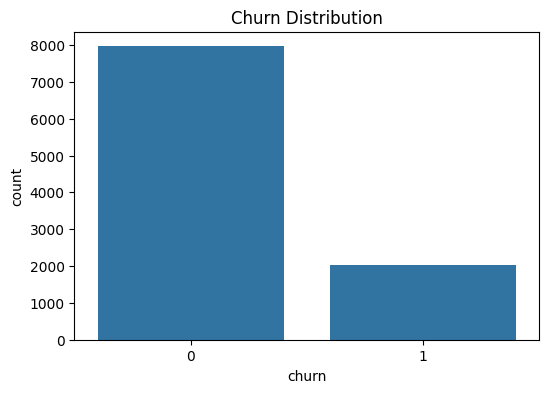

In [7]:
# Target variable analysis
print("Churn distribution:")
print(data['churn'].value_counts())
print("\nChurn percentage:")
print(data['churn'].value_counts(normalize=True) * 100)

# Visualize churn
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=data)
plt.title('Churn Distribution')
plt.show()

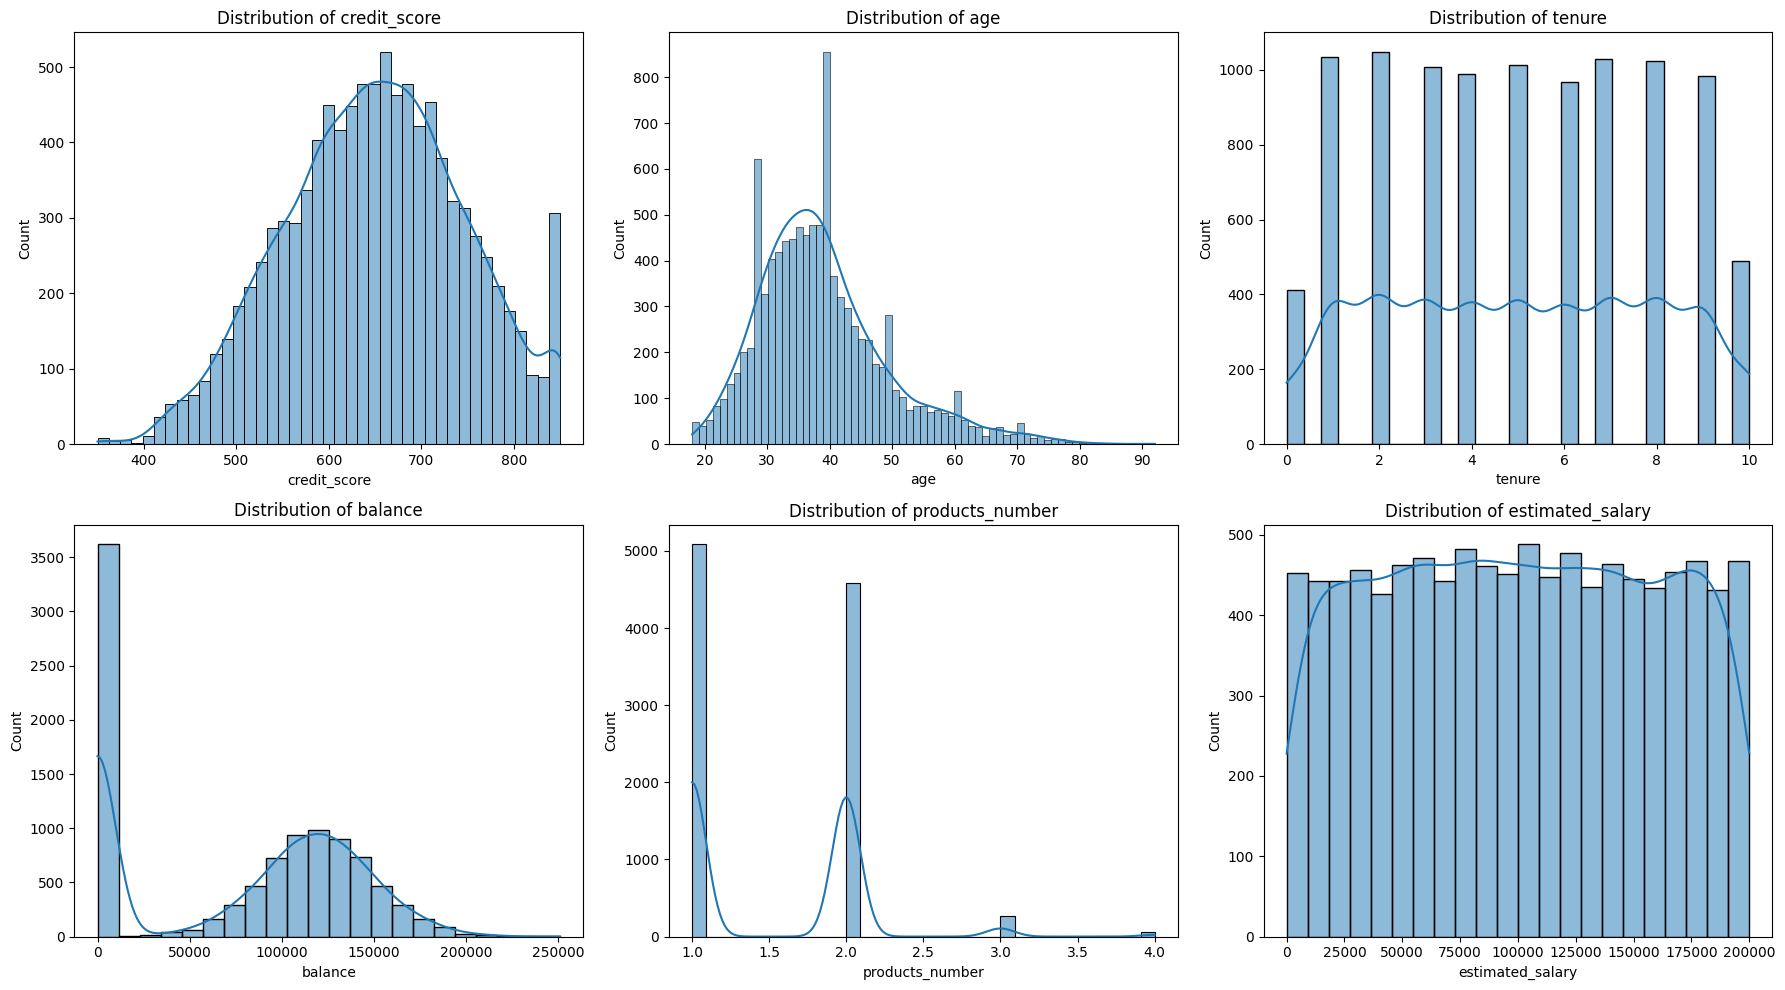

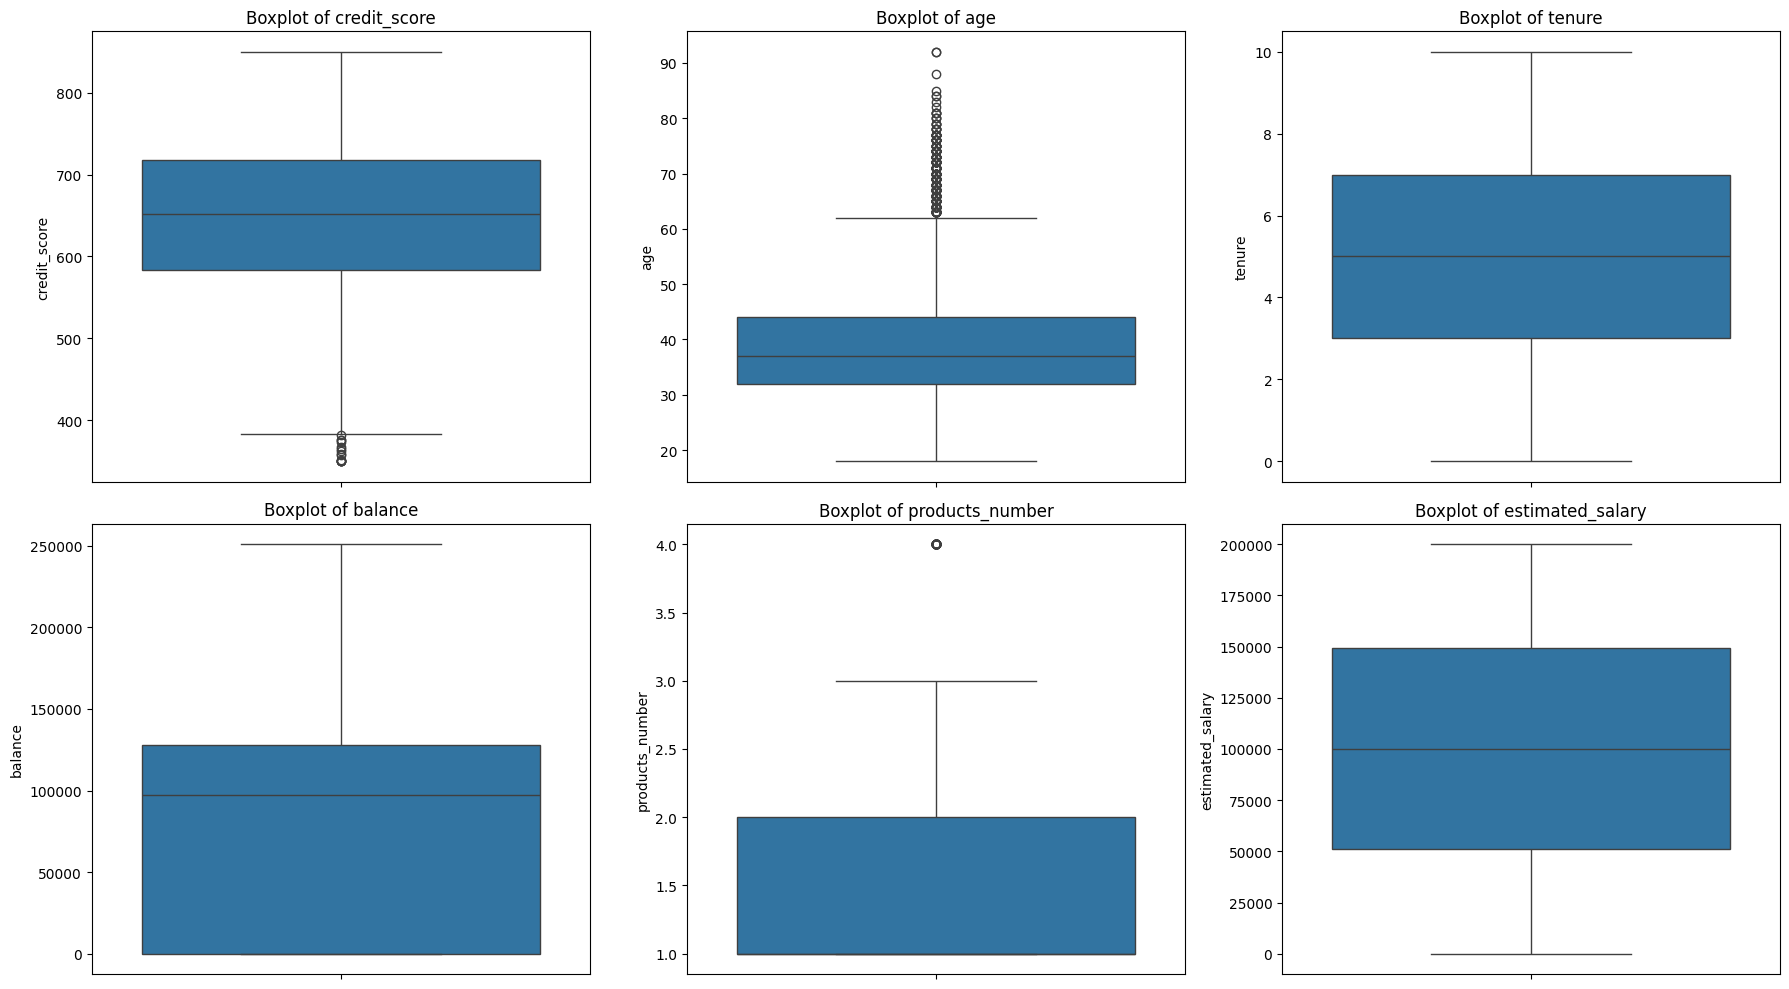

In [8]:
# Univariate analysis: Numerical variables
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
numerical_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

for i, col in enumerate(numerical_cols):
    ax = axes[i//3, i%3]
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# Boxplots for outliers
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(numerical_cols):
    ax = axes[i//3, i%3]
    sns.boxplot(y=data[col], ax=ax)
    ax.set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

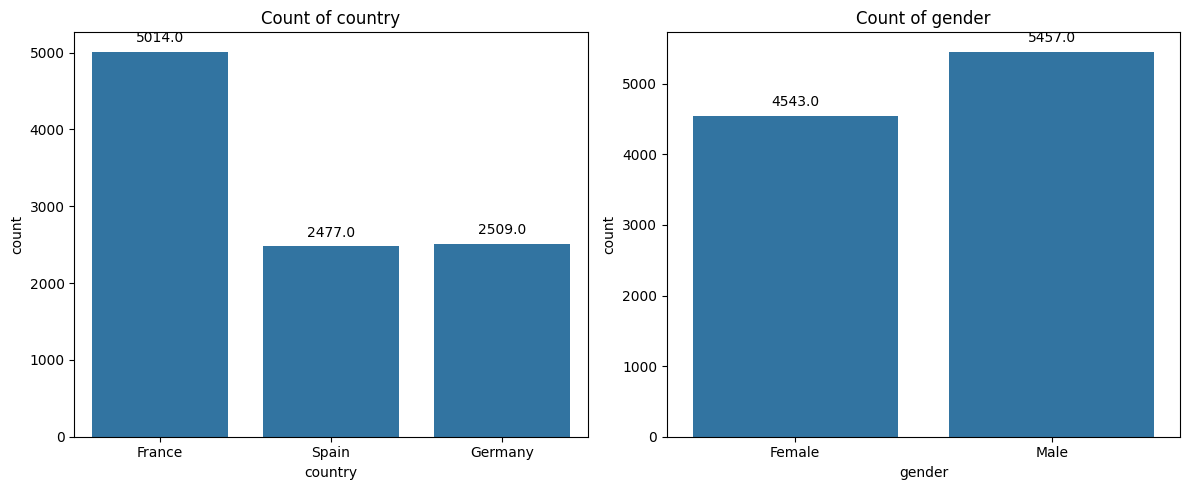

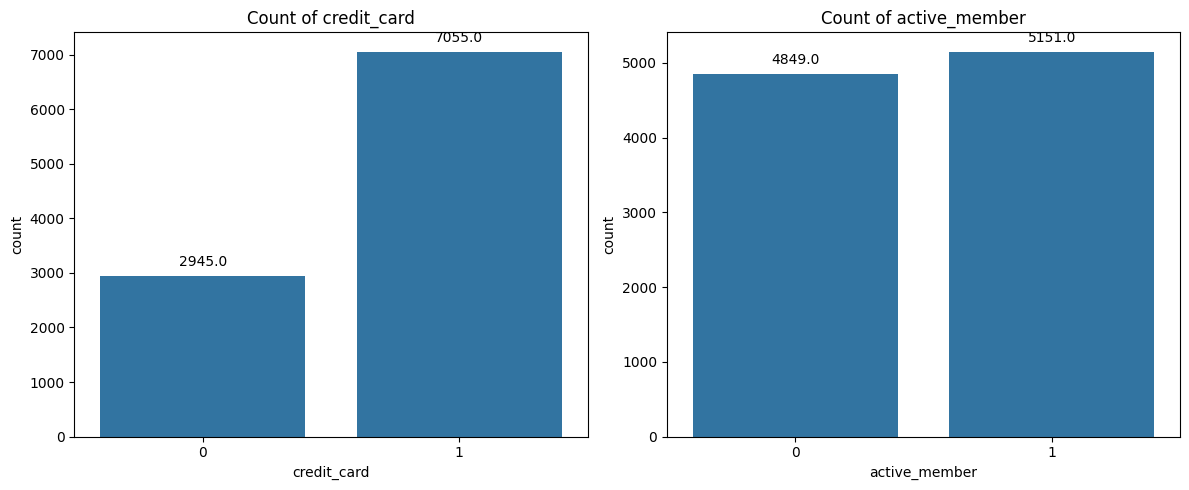

In [9]:
# Univariate analysis: Categorical variables
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
categorical_cols = ['country', 'gender']

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    sns.countplot(x=col, data=data, ax=ax)
    ax.set_title(f'Count of {col}')
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

# Binary variables: credit_card, active_member
binary_cols = ['credit_card', 'active_member']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(binary_cols):
    ax = axes[i]
    sns.countplot(x=col, data=data, ax=ax)
    ax.set_title(f'Count of {col}')
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

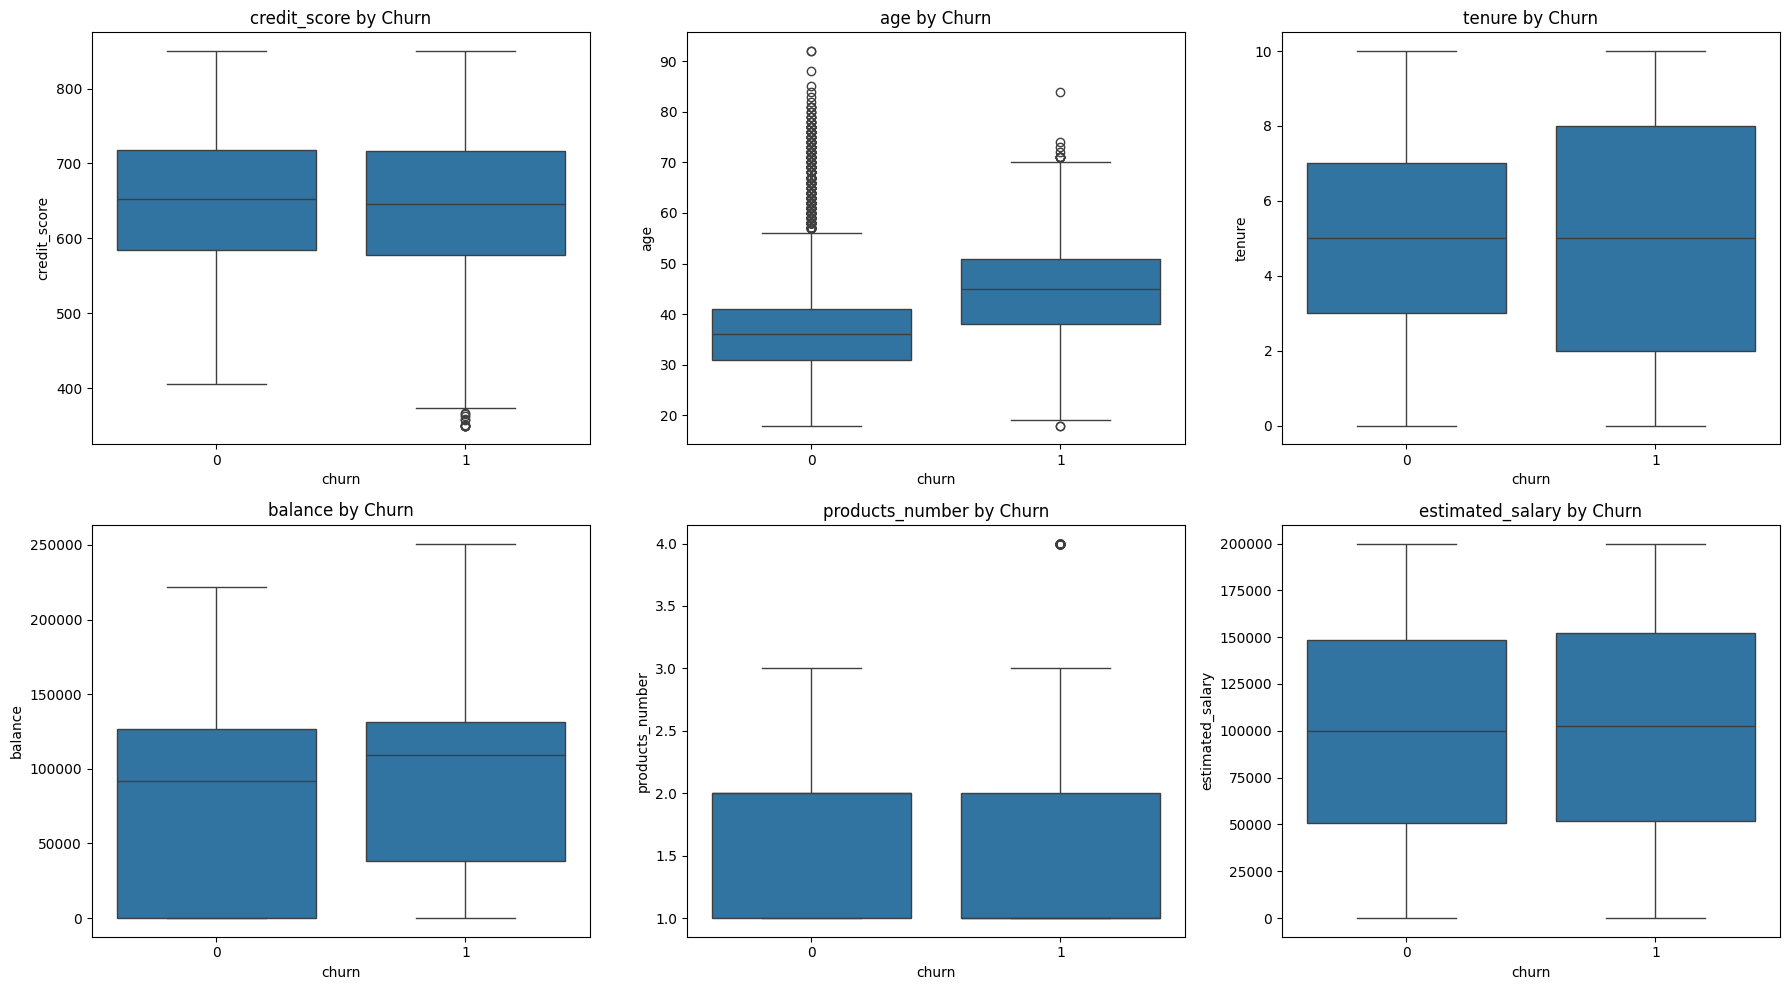

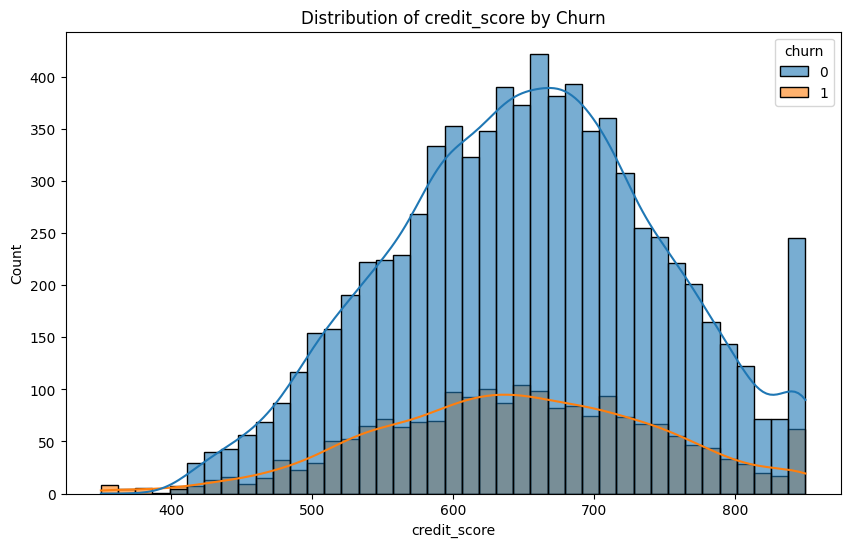

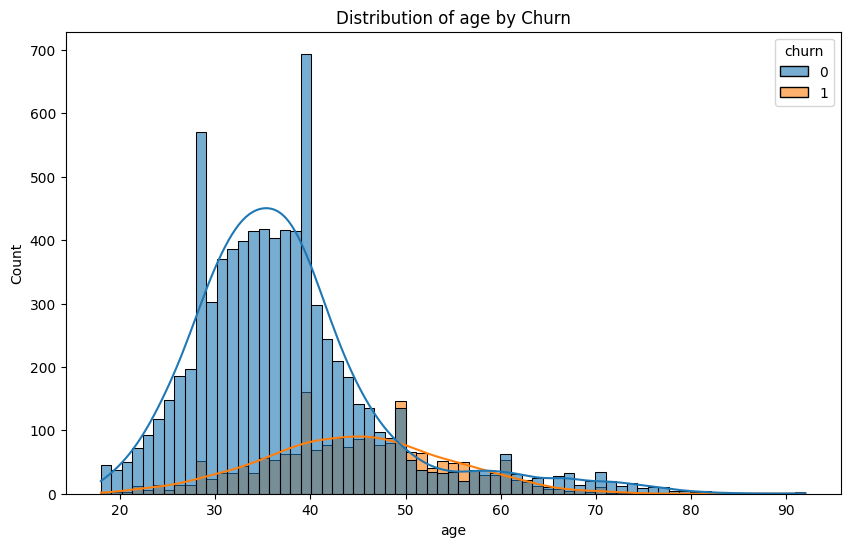

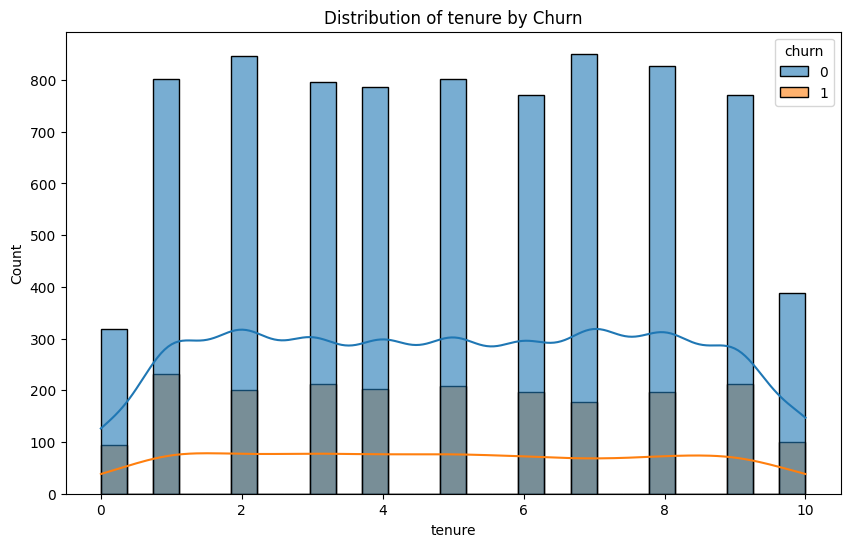

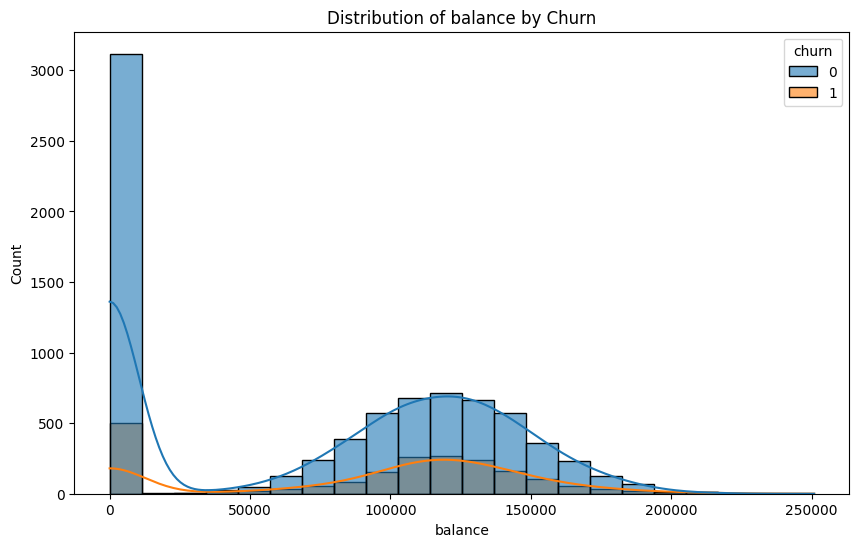

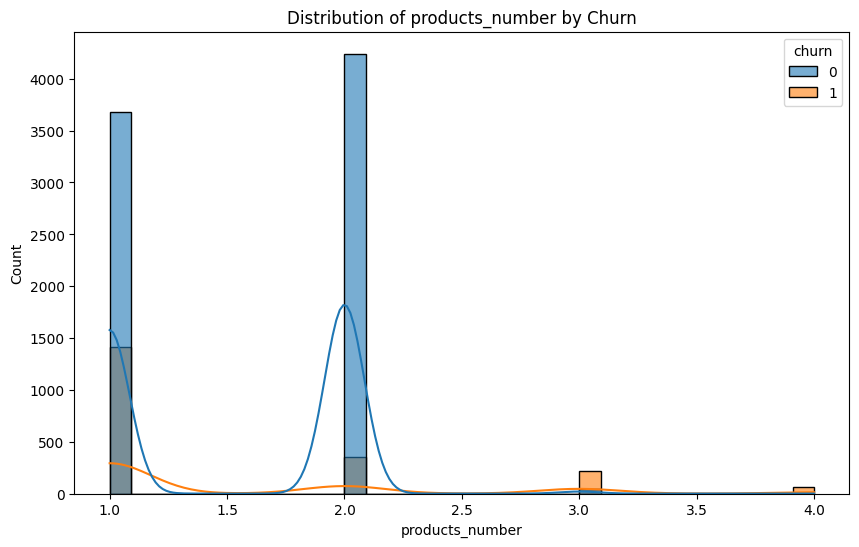

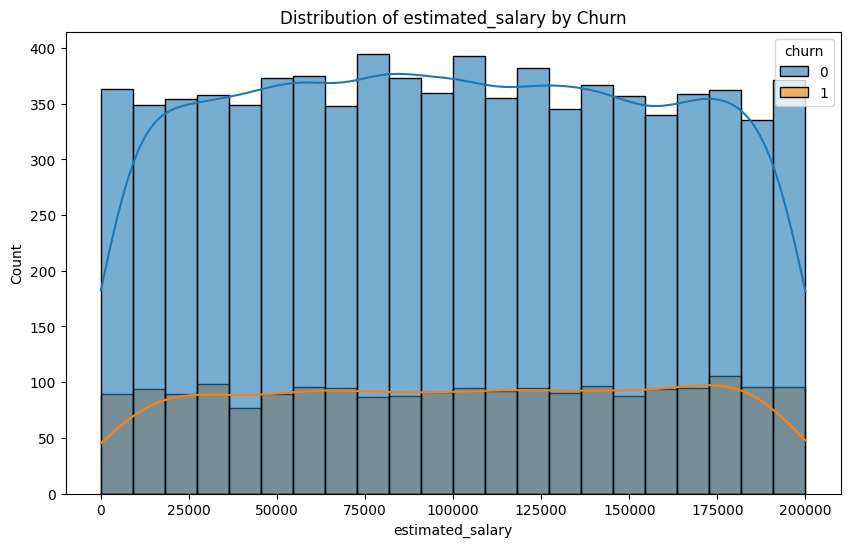

In [10]:
# Bivariate analysis: Numerical variables vs Churn
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
numerical_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

for i, col in enumerate(numerical_cols):
    ax = axes[i//3, i%3]
    sns.boxplot(x='churn', y=col, data=data, ax=ax)
    ax.set_title(f'{col} by Churn')

plt.tight_layout()
plt.show()

# Histograms by churn
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=data, x=col, hue='churn', kde=True, alpha=0.6)
    plt.title(f'Distribution of {col} by Churn')
    plt.show()

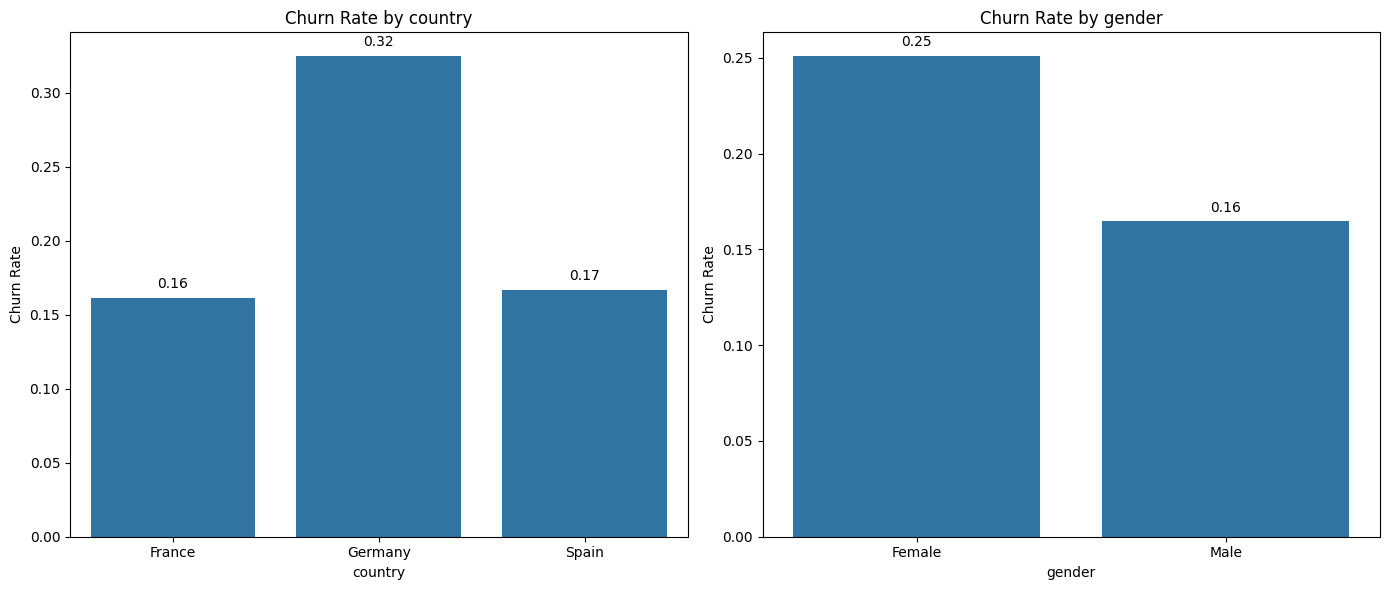

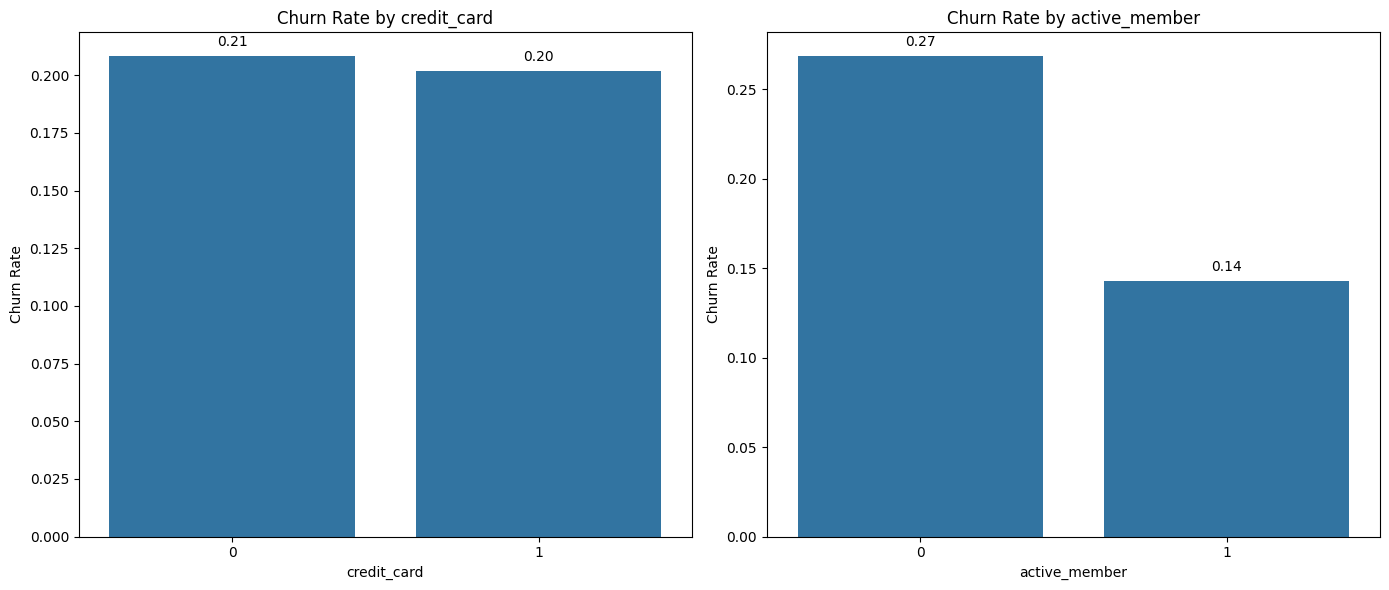


Cross-tabulation: country vs Churn
churn           0         1
country                    
France   0.838452  0.161548
Germany  0.675568  0.324432
Spain    0.833266  0.166734

Cross-tabulation: gender vs Churn
churn          0         1
gender                    
Female  0.749285  0.250715
Male    0.835441  0.164559

Cross-tabulation: credit_card vs Churn
churn               0         1
credit_card                    
0            0.791851  0.208149
1            0.798157  0.201843

Cross-tabulation: active_member vs Churn
churn                 0         1
active_member                    
0              0.731491  0.268509
1              0.857309  0.142691


In [11]:
# Bivariate analysis: Categorical variables vs Churn
categorical_cols = ['country', 'gender']
binary_cols = ['credit_card', 'active_member']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, col in enumerate(categorical_cols):
    ax = axes[i]
    churn_rate = data.groupby(col)['churn'].mean().reset_index()
    sns.barplot(x=col, y='churn', data=churn_rate, ax=ax)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

# Binary variables
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, col in enumerate(binary_cols):
    ax = axes[i]
    churn_rate = data.groupby(col)['churn'].mean().reset_index()
    sns.barplot(x=col, y='churn', data=churn_rate, ax=ax)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

# Cross-tabulations
for col in categorical_cols + binary_cols:
    print(f"\nCross-tabulation: {col} vs Churn")
    print(pd.crosstab(data[col], data['churn'], normalize='index'))

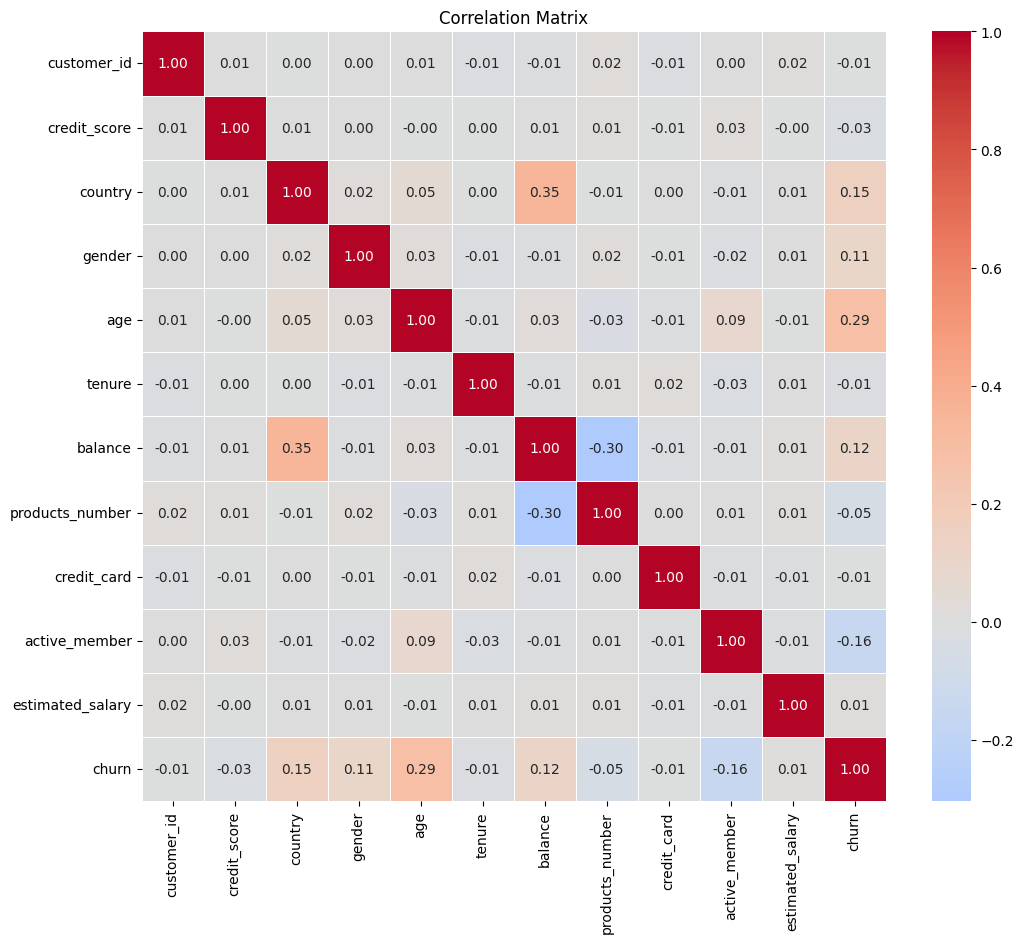

Correlations with Churn:
age                 0.285323
country             0.153771
balance             0.118533
gender              0.106512
estimated_salary    0.012097
customer_id        -0.006248
credit_card        -0.007138
tenure             -0.014001
credit_score       -0.027094
products_number    -0.047820
active_member      -0.156128
Name: churn, dtype: float64

Top positive correlations with churn:
age                 0.285323
country             0.153771
balance             0.118533
gender              0.106512
estimated_salary    0.012097
Name: churn, dtype: float64

Top negative correlations with churn:
active_member     -0.156128
products_number   -0.047820
credit_score      -0.027094
tenure            -0.014001
credit_card       -0.007138
Name: churn, dtype: float64


In [12]:
# Correlation analysis
# Encode categorical variables for correlation
data_encoded = data.copy()
data_encoded['country'] = data_encoded['country'].map({'France': 0, 'Spain': 1, 'Germany': 2})
data_encoded['gender'] = data_encoded['gender'].map({'Male': 0, 'Female': 1})

# Correlation matrix
corr_matrix = data_encoded.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# Correlation with churn
churn_corr = corr_matrix['churn'].drop('churn')
print("Correlations with Churn:")
print(churn_corr.sort_values(ascending=False))

# Top positive and negative correlations
print("\nTop positive correlations with churn:")
print(churn_corr[churn_corr > 0].sort_values(ascending=False).head(5))
print("\nTop negative correlations with churn:")
print(churn_corr[churn_corr < 0].sort_values().head(5))

In [13]:
# Statistical tests
from scipy.stats import chi2_contingency, ttest_ind

# Chi-square test for categorical variables
print("Chi-square tests for categorical variables:")
for col in categorical_cols + binary_cols:
    contingency_table = pd.crosstab(data[col], data['churn'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"{col}: Chi2 = {chi2:.2f}, p-value = {p:.4f}")

# T-test for numerical variables
print("\nT-tests for numerical variables:")
for col in numerical_cols:
    group0 = data[data['churn'] == 0][col]
    group1 = data[data['churn'] == 1][col]
    t_stat, p_val = ttest_ind(group0, group1)
    print(f"{col}: t-stat = {t_stat:.2f}, p-value = {p_val:.4f}")

Chi-square tests for categorical variables:
country: Chi2 = 301.26, p-value = 0.0000
gender: Chi2 = 112.92, p-value = 0.0000
credit_card: Chi2 = 0.47, p-value = 0.4924
active_member: Chi2 = 242.99, p-value = 0.0000

T-tests for numerical variables:
credit_score: t-stat = 2.71, p-value = 0.0067
age: t-stat = -29.77, p-value = 0.0000
tenure: t-stat = 1.40, p-value = 0.1615
balance: t-stat = -11.94, p-value = 0.0000
products_number: t-stat = 4.79, p-value = 0.0000
estimated_salary: t-stat = -1.21, p-value = 0.2264


In [14]:
# Outlier analysis using IQR
print("Outlier analysis (IQR method):")
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.2f}%)")

# Summary insights
print("\n=== EDA Summary ===")
print("1. Dataset: 10,000 customers, no missing values, no duplicates.")
print("2. Target imbalance: 79.6% non-churn, 20.4% churn.")
print("3. Key drivers of churn:")
print("   - Age: Older customers more likely to churn.")
print("   - Country: Germany has highest churn rate (32%).")
print("   - Balance: Higher balance correlates with churn.")
print("   - Gender: Females slightly more likely to churn.")
print("   - Active Member: Active members less likely to churn.")
print("   - Products Number: More products, less churn.")
print("4. Non-significant variables: Credit card ownership, tenure, estimated salary.")
print("5. Outliers present in credit_score, age, balance, etc., but may be valid data.")

Outlier analysis (IQR method):
credit_score: 15 outliers (0.15%)
age: 359 outliers (3.59%)
tenure: 0 outliers (0.00%)
balance: 0 outliers (0.00%)
products_number: 60 outliers (0.60%)
estimated_salary: 0 outliers (0.00%)

=== EDA Summary ===
1. Dataset: 10,000 customers, no missing values, no duplicates.
2. Target imbalance: 79.6% non-churn, 20.4% churn.
3. Key drivers of churn:
   - Age: Older customers more likely to churn.
   - Country: Germany has highest churn rate (32%).
   - Balance: Higher balance correlates with churn.
   - Gender: Females slightly more likely to churn.
   - Active Member: Active members less likely to churn.
   - Products Number: More products, less churn.
4. Non-significant variables: Credit card ownership, tenure, estimated salary.
5. Outliers present in credit_score, age, balance, etc., but may be valid data.
